<a href="https://colab.research.google.com/github/pachterlab/CJP_2025/blob/main/notebooks/frhoPCA_berkeley.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, sys, scipy.integrate

repo_dir = "/content/CFPCA"

!apt-get install -qq git-lfs
!pip install -q scikit-fda numpy matplotlib scipy

if not os.path.exists(repo_dir):
    !git clone https://github.com/ezhang1218/CFPCA.git {repo_dir}
else:
    print("CFPCA repo already exists, skipping clone.")

os.chdir(repo_dir)

if repo_dir not in sys.path:
    sys.path.append(repo_dir)

if not hasattr(scipy.integrate, "simps"):
    scipy.integrate.simps = scipy.integrate.simpson



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.6/488.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.4 MB/s eta 0:00:00
Cloning into '/content/CFPCA'...
remote: Enumerating objects: 189, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 189 (delta 43), reused 7 (delta 7), pack-reused 104 (from 1)
Receiving objects: 100% (189/189), 9.70 MiB | 16.69 MiB/s, done.
Resolving deltas: 100% (74/74), done.


In [34]:
from main import *


import matplotlib.pyplot as plt
import numpy as np
import skfda
from skfda.datasets import fetch_growth
from skfda.preprocessing.dim_reduction import FPCA
from skfda.representation.basis import BSplineBasis

from scipy.linalg import eigh

fs = 15

<Figure size 1200x600 with 0 Axes>

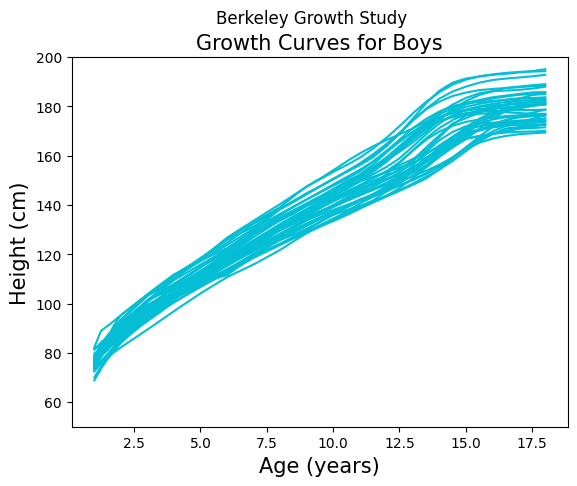

<Figure size 1200x600 with 0 Axes>

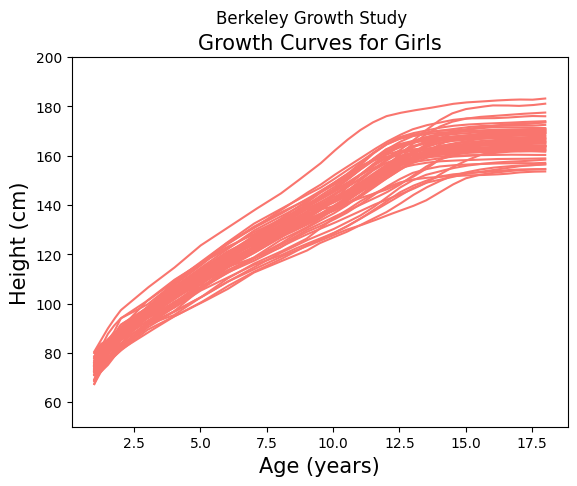

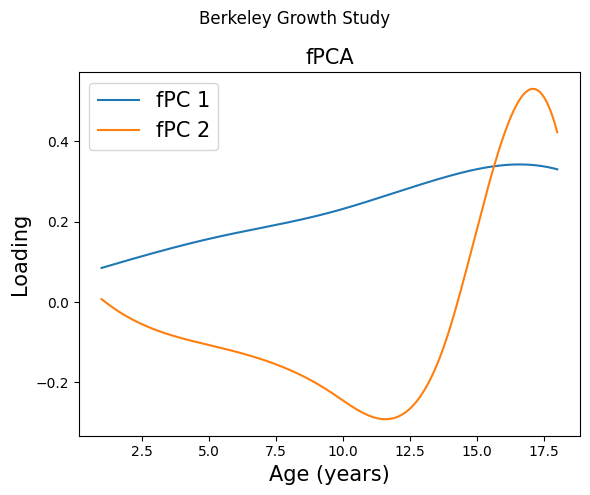

In [50]:
# --- Load dataset ---
dataset = fetch_growth()
fd = dataset['data']
y = np.array(dataset['target'])

boys_mask = (y == 0)
girls_mask = (y == 1)

boys_fd = fd[boys_mask]
girls_fd = fd[girls_mask]

# --- Plot growth curves for boys ---
plt.figure(figsize=(12, 6))
boys_fd.plot(c='#04BED5')
plt.xlabel("Age (years)", fontsize=fs)
plt.ylabel("Height (cm)", fontsize=fs)
plt.title("Growth Curves for Boys", fontsize=15)
plt.ylim(50, 200)
# plt.legend(fontsize=14)
plt.show()

# --- Plot growth curves for girls ---
plt.figure(figsize=(12, 6))
girls_fd.plot(c='#F9756E')
plt.xlabel("Age (years)", fontsize=fs)
plt.ylabel("Height (cm)", fontsize=fs)
plt.title("Growth Curves for Girls", fontsize=fs)
plt.ylim(50, 200)
# plt.legend(fontsize=14)
plt.show()



fig,ax_ = plt.subplots(1,1,figsize=(6, 5))


# for ind,n in zip([(0,0),(0,1),(0,2),(0,3),(1,0),(1,1),(1,2),(1,3)],[4,5,7,8,9,10,15,20]):
for ind,n in zip([(0,0)],[7]):
  # --- FPCA on BSpline basis for comparison ---
  basis = BSplineBasis(n_basis=7)
  basis_fd = fd.to_basis(basis)
  fpca = FPCA(n_components=2)
  fpca.fit(basis_fd)

  fpca.components_.plot(legend=False,axes=ax_)
  ax_.legend(['fPC 1', 'fPC 2'], fontsize=fs)
  ax_.set_xlabel("Age (years)", fontsize=fs)
  ax_.set_ylabel("Loading", fontsize=fs)
  ax_.set_title(f"fPCA", fontsize=fs)

plt.tight_layout()
plt.show()

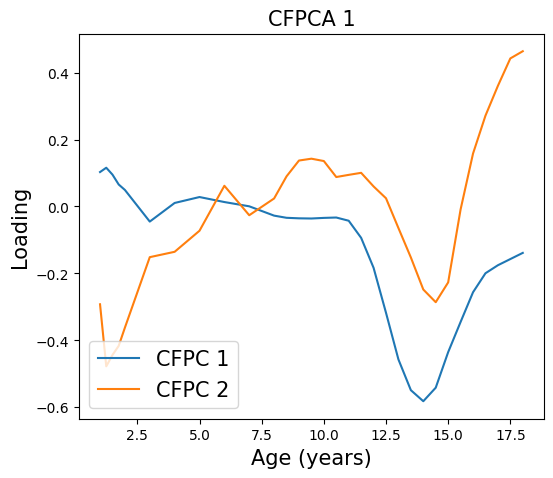

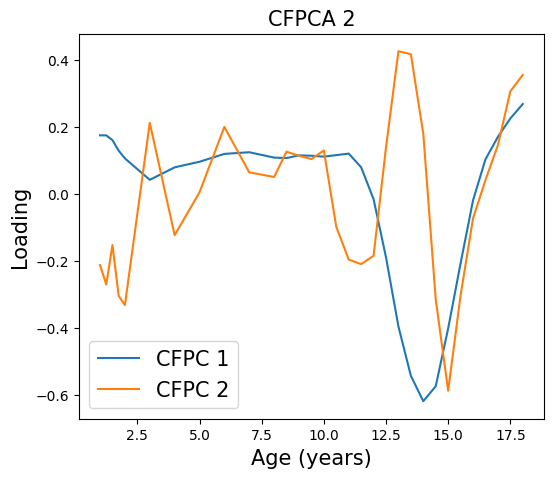

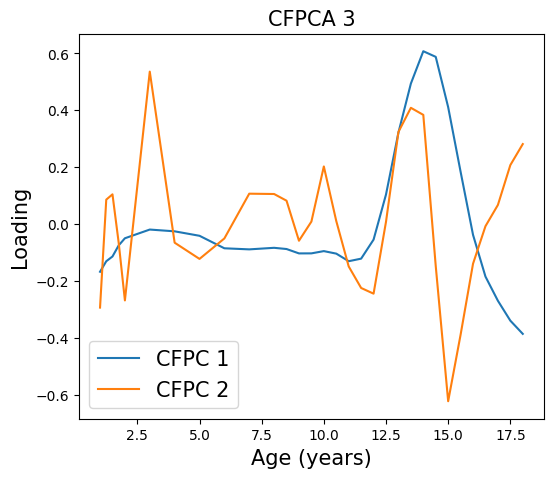

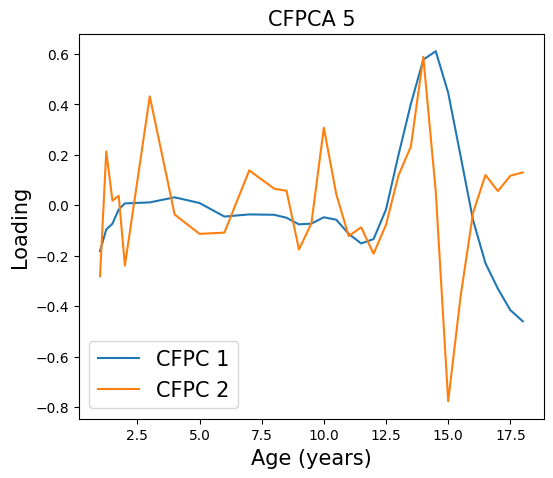

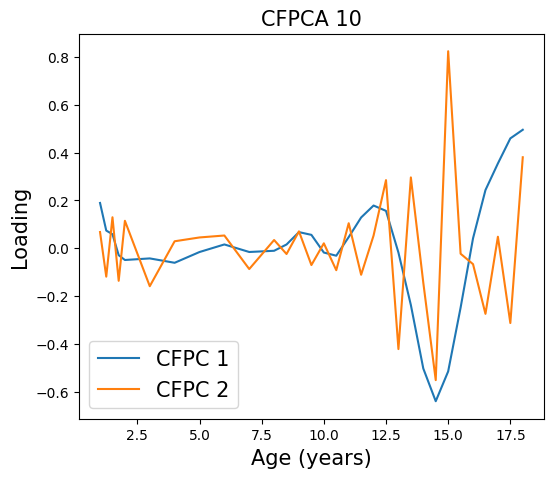

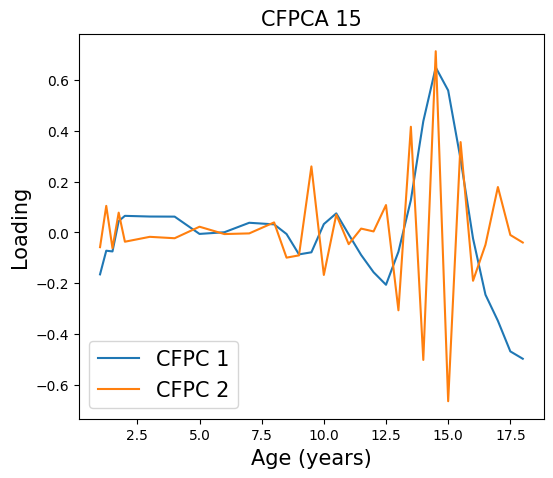

In [52]:
# Convert functional data to lists for CFPCA
boys_height = fd.data_matrix[boys_mask]
girls_height = fd.data_matrix[girls_mask]
boys_list = [sub_array.flatten().tolist() for sub_array in boys_height]
girls_list = [sub_array.flatten().tolist() for sub_array in girls_height]

t = fd.grid_points[0]

for n in [1,2,3,5,10,15]:
  components = CFPCA(boys_list, girls_list, n, t, False, True)[0]

  plt.figure(figsize=(6, 5))
  plt.plot(t, components[:, 0], label='CFPC 1')
  plt.plot(t, components[:, 1], label='CFPC 2')
  plt.xlabel("Age (years)", fontsize=fs)
  plt.ylabel("Loading", fontsize=fs)
  plt.title(f"CFPCA {n}", fontsize=fs)
  plt.legend(fontsize=fs, loc="lower left")
  plt.show()

# B-spline rhoPCA

In [40]:
def rho_fpca_basis(A_fg_c, A_bg_c, G, eps=1e-6):
    """
    Functional ρPCA in basis using Gram-matrix geometry. Returns evecs as coefficients of basis.
    """

    l_matrix = np.linalg.cholesky(G)
    l_inv_g_t = scipy.linalg.solve_triangular(
            l_matrix,
            np.transpose(G),
            lower=True)

    whitened_fg = A_fg_c @ np.transpose(l_inv_g_t)
    whitened_bg = A_bg_c @ np.transpose(l_inv_g_t)
    cov_fg = np.cov(whitened_fg, rowvar=False)
    cov_bg = np.cov(whitened_bg, rowvar=False)

    vals, vecs = eigh(cov_fg , cov_bg)
    vecs = scipy.linalg.solve_triangular(l_matrix.T, vecs, lower=False)   # the vectors are not transposed like in sklearn-fpca because eigh has different convention than PCA
    # idx = np.argsort(vals)[::-1]

    # return vals[idx], vecs[:, idx]
    # fix convention of returned vecs
    for i,vec_ in enumerate(vecs.T):
        max_ = np.where(np.abs(vec_) == np.max(np.abs(vec_)))[0]
        if vec_[max_] < 0:
            vec_ *= -1
        vecs[:,i] = vec_
    return vals, vecs

/tmp/ipykernel_151/2019335890.py:34: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the functional data object instead.
  GE1_smooth = GE1_fd.evaluate(ages).ravel()
/tmp/ipykernel_151/2019335890.py:35: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the functional data object instead.
  GE2_smooth = GE2_fd.evaluate(ages).ravel()


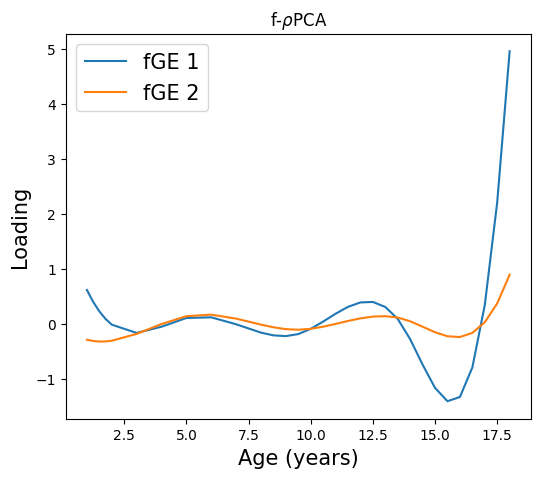

In [48]:

X_fg = boys_fd.data_matrix[..., 0]   # shape (n_boys, n_timepoints)
X_bg = girls_fd.data_matrix[..., 0]  # shape (n_girls, n_timepoints)
ages = boys_fd.grid_points[0]        # time/age grid

fig,ax_ = plt.subplots(1,1,figsize=(6, 5))


basis = BSplineBasis(n_basis=7, domain_range=(ages[0], ages[-1]))
# basis = FourierBasis(n_basis=n, domain_range=(ages[0], ages[-1]))
# basis = MonomialBasis(n_basis = n)

fg_basis_fd = skfda.FDataGrid(X_fg, ages).to_basis(basis)
bg_basis_fd = skfda.FDataGrid(X_bg, ages).to_basis(basis)
A_fg = fg_basis_fd.coefficients   # shape (n_subjects_fg, n_basis)
A_bg = bg_basis_fd.coefficients   # shape (n_subjects_bg, n_basis)


A_fg_c = A_fg - A_fg.mean(axis=0)
A_bg_c = A_bg - A_bg.mean(axis=0)


G = basis.gram_matrix()

rho_vals, rho_vecs = rho_fpca_basis(A_fg_c, A_bg_c,G)
# rho_vecs = rho_vecs.T

GE1_coeffs = rho_vecs[:,-1]
GE2_coeffs = rho_vecs[:,-2]

GE1_fd = skfda.representation.basis.FDataBasis(basis, GE1_coeffs)
GE2_fd = skfda.representation.basis.FDataBasis(basis, GE2_coeffs)


GE1_smooth = GE1_fd.evaluate(ages).ravel()
GE2_smooth = GE2_fd.evaluate(ages).ravel()



ax_.set_title(r"f-$\rho$PCA")
ax_.plot(ages, GE1_smooth, label="fGE 1")
ax_.plot(ages, GE2_smooth, label="fGE 2")


ax_.set_xlabel("Age (years)", fontsize = fs)
ax_.set_ylabel("Loading", fontsize=fs)
ax_.legend(fontsize=fs)

plt.show()